# Qt-Ft Agglomeration Simulation

This notebook runs ReaDDy2-based simulations of Qt-Ft nanoparticle agglomeration.

**Structure:** all code lives in the `qtft` package
- `qtft.config` / `qtft.system` / `qtft.engine` — configuration + simulation
- `qtft.analysis` — analysis (matplotlib-free); `qtft.plotting` — plotting
- `qtft.ensemble` — `EnsembleSimulation` for multi-replica runs

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import readdy
import sys
import os

# Import the qtft package
import qtft as sim
import qtft.analysis as analysis
import qtft.plotting as plotting
from qtft import EnsembleSimulation

print(f"ReaDDy: {readdy.__version__}")
print(f"Python: {sys.version}")

ReaDDy: 2.0.13-5
Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]


## 2. Module Reload Helper

In [2]:
import importlib
import qtft, qtft.config, qtft.system, qtft.engine, qtft.analysis, qtft.plotting, qtft.ensemble

# Reload submodules in dependency order (restart the kernel for deep changes).
for _m in (qtft.config, qtft.system, qtft.engine, qtft.analysis,
           qtft.plotting, qtft.ensemble, qtft):
    importlib.reload(_m)

sim = qtft
analysis = qtft.analysis
plotting = qtft.plotting
from qtft import EnsembleSimulation
print("Modules reloaded")

Modules reloaded


## 3. Configuration

In [3]:
# ============================================================
# SIMULATION CONFIGURATION
# ============================================================
# Modify parameters here and re-run this cell

# ----- Output options -----
SAVE_PLOTS = True   # set True to write single-run plot SVGs to disk
OUTPUT_ROOT = "Simulation_Files_Single_Runs"   # parent folder for single-run output

config = sim.SimulationConfig(
    # ----- Particle properties -----
    qt=sim.ParticleConfig(
        name="Qt",
        radius=21.0,             # nm (Encapsulin)
        diffusion=0.5,           # nm^2/ns
        cluster_diffusion=0.3,   # nm^2/ns
    ),
    ft=sim.ParticleConfig(
        name="Ft",
        radius=6.0,             # nm (Ferritin)
        diffusion=1.0,           # nm^2/ns
        cluster_diffusion=0.7,   # nm^2/ns
    ),
    
    # ----- Topology/binding parameters -----
    topology=sim.TopologyConfig(
        name="QtFt_Cluster",
        binding_radius=27.25,     # nm (r_Qt + r_Ft = 21 + 6 + buffer)
        kon=0.001,               # nm^3/(ns*particles) (binding rate)
        k_bond=10.0,             # kJ/(mol*nm^2) (bond stiffness)
        ft_monovalent=False,     # True -> Ft caps at 1 bond (single-Qt-star clusters); adds _FtMono filename tag
    ),
    
    # ----- Lennard-Jones parameters -----
    # Per-pair epsilon values (kJ/mol). Cluster and mixed-state values
    # cascade from free-free values by default if not specified.
    # Set any epsilon to 0 to disable that interaction entirely.
    lj=sim.LennardJonesConfig(
        epsilon_QtQt=1.5,        # kJ/mol - Qt-Qt interaction (~4 kT)
        epsilon_FtFt=1.5,        # kJ/mol - Ft-Ft interaction
        epsilon_QtFt=3.0,        # kJ/mol - Qt-Ft interaction
        epsilon_QtCQtC=None,   # defaults to epsilon_QtQt
        epsilon_FtCFtC=None,   # defaults to epsilon_FtFt
        epsilon_QtCFtC=None,   # defaults to epsilon_QtFt (set to 0 to disable)
        potential_type="WCA",    # "WCA" (purely repulsive) or "LJ" (with attraction)
    ),
    
    # ----- Simulation box -----
    box_size=(500,500,500),  # nm (larger box for larger particles)
    periodic_boundary=True,
    temperature=300.0,             # Kelvin
    
    # ----- Integration -----
    timestep=5e-2,              # ns (0.05 ns = 50 ps)
    n_steps=2000000,              # Total steps  # before 2000000
    
    # ----- Recording -----
    record_stride=100,              # Save trajectory every N steps
    observable_stride=100,          # Record observables every N steps
    particles_observable_stride=1000,  # Enables faster analysis (10x coarser than trajectory)
                                       # Set to None to disable and save disk space
    
    # ----- Particles -----
    n_qt=200,                  # Number of Qt particles
    n_ft=400,                      # Number of Ft particles
    
    # ----- Execution -----
    kernel="CPU",
    n_threads=4,
    rng_seed=22,
    
    # ----- Output -----
    # output_file is auto-generated from parameters, e.g.:
    # qt_ft_200Qt_400Ft_WCA_eQQ7_eFF7_eQF7_kon175_dt10ps_59us.h5
    # Uncomment to override: output_file="custom_name.h5",
)

# ----- Collect all single-run output (h5/xyz/tcl/json) into a per-run subfolder -----
# config is rebuilt fresh on each run, so config.output_file is the bare basename here.
# Keep these lines inside this cell to avoid double-prepending the directory.
RUN_DIR = os.path.join(OUTPUT_ROOT, config.output_file[:-3])   # drop ".h5" -> subfolder name
os.makedirs(RUN_DIR, exist_ok=True)
config.output_file = os.path.join(RUN_DIR, config.output_file)

# Print configuration summary
config.print_summary()

SIMULATION CONFIGURATION

Particles:
  Qt: r=21.0 nm, D=0.5 nm²/ns (cluster: D=0.3)
  Ft: r=6.0 nm, D=1.0 nm²/ns (cluster: D=0.7)
  Counts: 200 Qt + 400 Ft = 600 total

Topology:
  Binding radius: 27.25 nm
  Binding rate (kon): 0.001 nm³/(ns·part)
  Bond stiffness: 10.0 kJ/(mol·nm²)
  Equilibrium bond length: 27.0 nm

Lennard-Jones:
  Potential type: WCA
  Cutoff factor: 1.122
  ε Qt-Qt: 1.5 kJ/mol
  ε Ft-Ft: 1.5 kJ/mol
  ε Qt-Ft: 3.0 kJ/mol
  Cluster/mixed ε: same as free (default)

Simulation:
  Box: 500 × 500 × 500 nm
  Temperature: 300.0 K
  Equilibration potential: WCA
  Timestep: 0.05 ns (50.00 ps)
  Steps: 2,000,000 (100.0 µs total)
  Output: Simulation_Files_Single_Runs/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us.h5


## 4. Run Simulation

In [13]:
# Equilibration
pos_qt, pos_ft = sim.equilibrate_system(config, n_steps=10000)

# Production
system = sim.create_system(config)
simulation = sim.create_simulation(system, config, overwrite=True)
sim.place_particles(simulation, config, positions_qt=pos_qt, positions_ft=pos_ft)
trajectory = sim.run_simulation(simulation, config)

# Summary
analysis.print_analysis_summary(config.output_file, config)


EQUILIBRATION
  Running 10,000 steps without reactions (WCA potential)

✓ Species: Qt, Ft, QtC, FtC
✓ WCA potentials (10 registered): ε_QQ=1.5, ε_FF=1.5, ε_QF=3.0
✓ Topology 'QtFt_Cluster': bonds configured, reactions DISABLED (equilibration mode)
✓ System created: 500×500×500 nm box (equilibration mode - no reactions)
✓ Placed 200 Qt + 400 Ft particles (random)
  Running equilibration...
Configured kernel context with:
--------------------------------
 - kBT = 2.4361377615198827
 - periodic b.c. = (true, true, true)
 - box size = (500, 500, 500)
 - particle types:
     * Topology particle type "FtC" with D=0.7
     * Topology particle type "QtC" with D=0.3
     * Topology particle type "Ft" with D=1
     * Topology particle type "Qt" with D=0.5
 - potentials of order 2:
     * for types "QtC" and "Ft"
         * 12-6-Lennard-Jones potential with cutoff=26.999998837953523, epsilon=3, k=12, and with energy shift
     * for types "Qt" and "QtC"
         * 12-6-Lennard-Jones potential wi

100%|██████████| 1000/1000 [00:06<00:00, 145.98it/s]


[2026-06-16 12:39:53] [info] Simulation completed

EQUILIBRATION COMPLETE
  Retrieved 200 Qt + 400 Ft positions

✓ Species: Qt, Ft, QtC, FtC
✓ LJ potentials (10 registered): ε_QQ=1.5, ε_FF=1.5, ε_QF=3.0
✓ Topology 'QtFt_Cluster': binding_radius=27.25 nm, kon=0.001, k_bond=10.0
✓ System created: 500×500×500 nm box
✓ Observables registered (stride=100, forces/virial stride=10000, particles observable stride=1000)
✓ Simulation created: CPU kernel, 4 threads
✓ Placed 200 Qt (provided) + 400 Ft (provided) particles

RUNNING SIMULATION
  Particles: 200 Qt + 400 Ft
  Duration: 100.0 µs (2,000,000 steps)

Configured kernel context with:
--------------------------------
 - kBT = 2.4361377615198827
 - periodic b.c. = (true, true, true)
 - box size = (500, 500, 500)
 - particle types:
     * Topology particle type "FtC" with D=0.7
     * Topology particle type "QtC" with D=0.3
     * Topology particle type "Ft" with D=1
     * Topology particle type "Qt" with D=0.5
 - potentials of order 2:
     

100%|██████████| 200000/200000 [1:45:01<00:00, 31.74it/s]


[2026-06-16 14:24:55] [info] Simulation completed

SIMULATION COMPLETE

  Bond counting: Method 1 (topology.edges) - exact count

SIMULATION RESULTS SUMMARY

Initial state (t=0):
  Topologies: 600
  Average size: 1.00 particles
  Largest: 1 particles
  Bonds: 0

Final state (t=100.00 µs):
  Topologies: 4
  Average size: 150.00 particles
  Largest: 221 particles
  Bonds: 596

Final size distribution:
  Median: 147.5
  Mean: 150.0
  Std: 50.2
  Range: 84 - 221

Particle distribution:
  Monomers (1): 0 particles (0.0%)
  Small (2-12): 0 particles (0.0%)
  Medium (13-60): 0 particles (0.0%)
  Large (61-150): 213 particles (35.5%)
  Very large (>150): 387 particles (64.5%)




Generating observable plots...
  Bond counting: Method 1 (topology.edges) - exact count
✓ Saved plot to plots_observables.svg


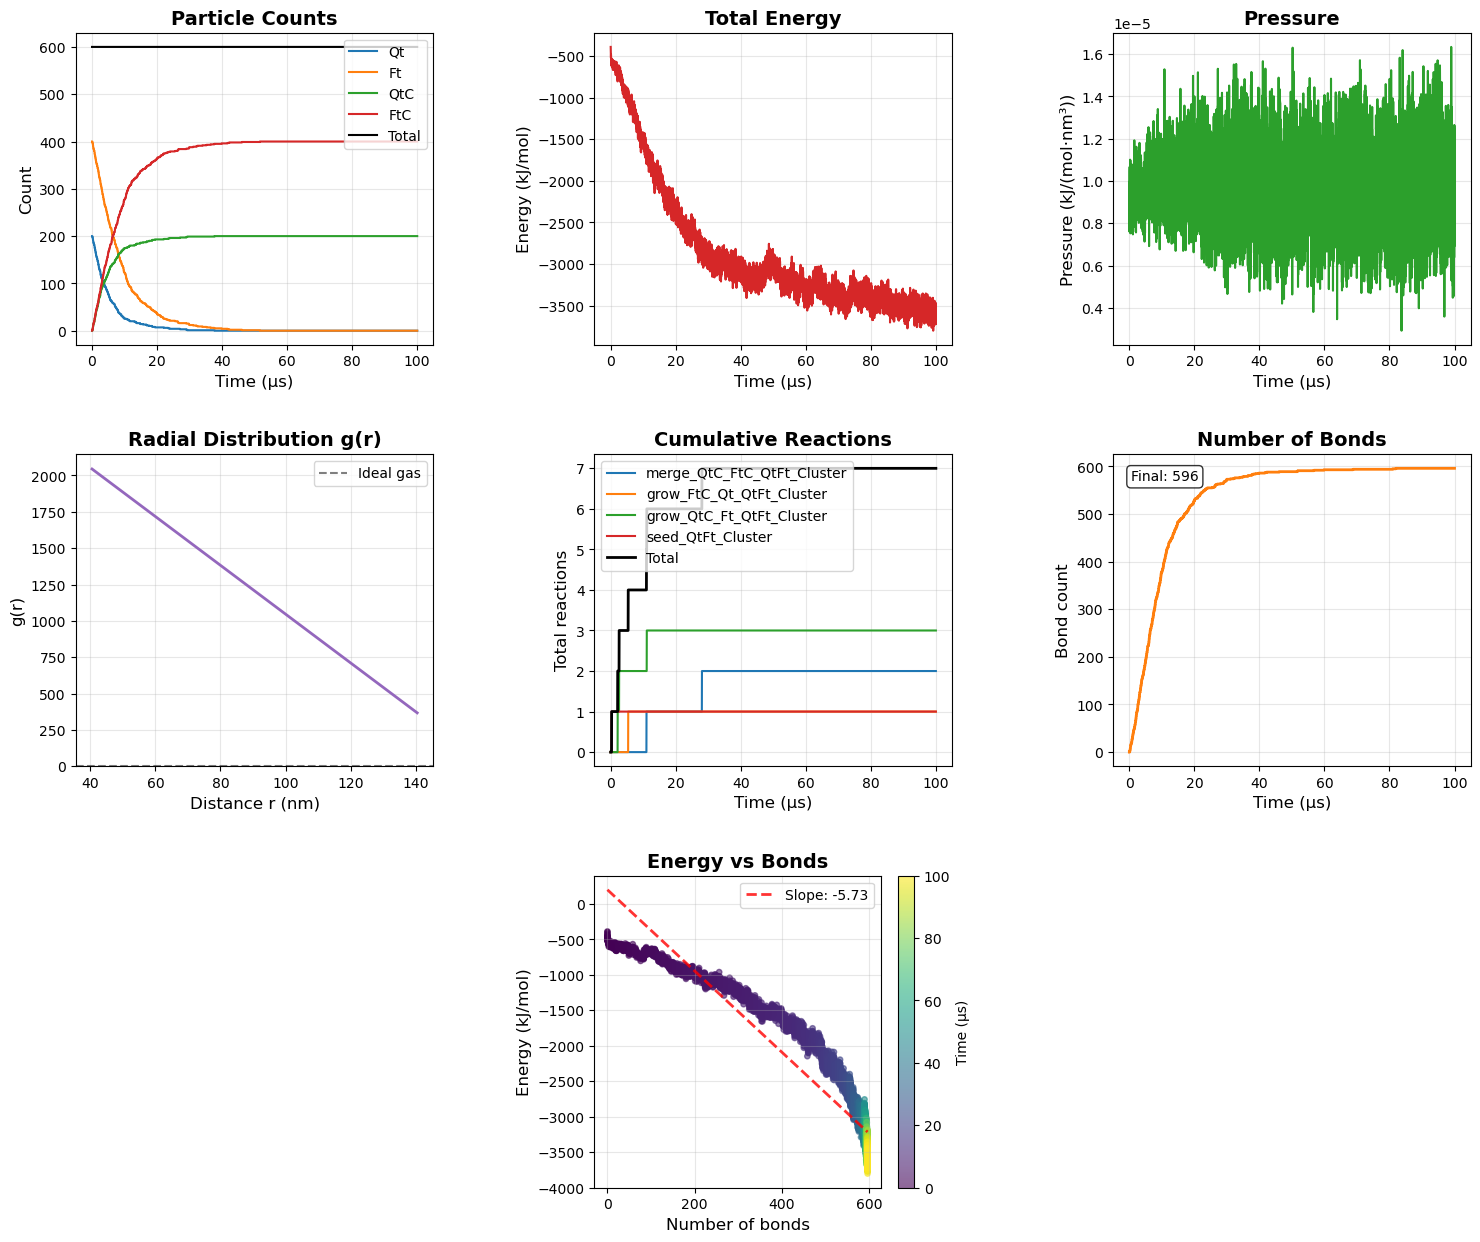


Generating cluster analysis plots...
✓ Saved plot to plots_clusters.svg


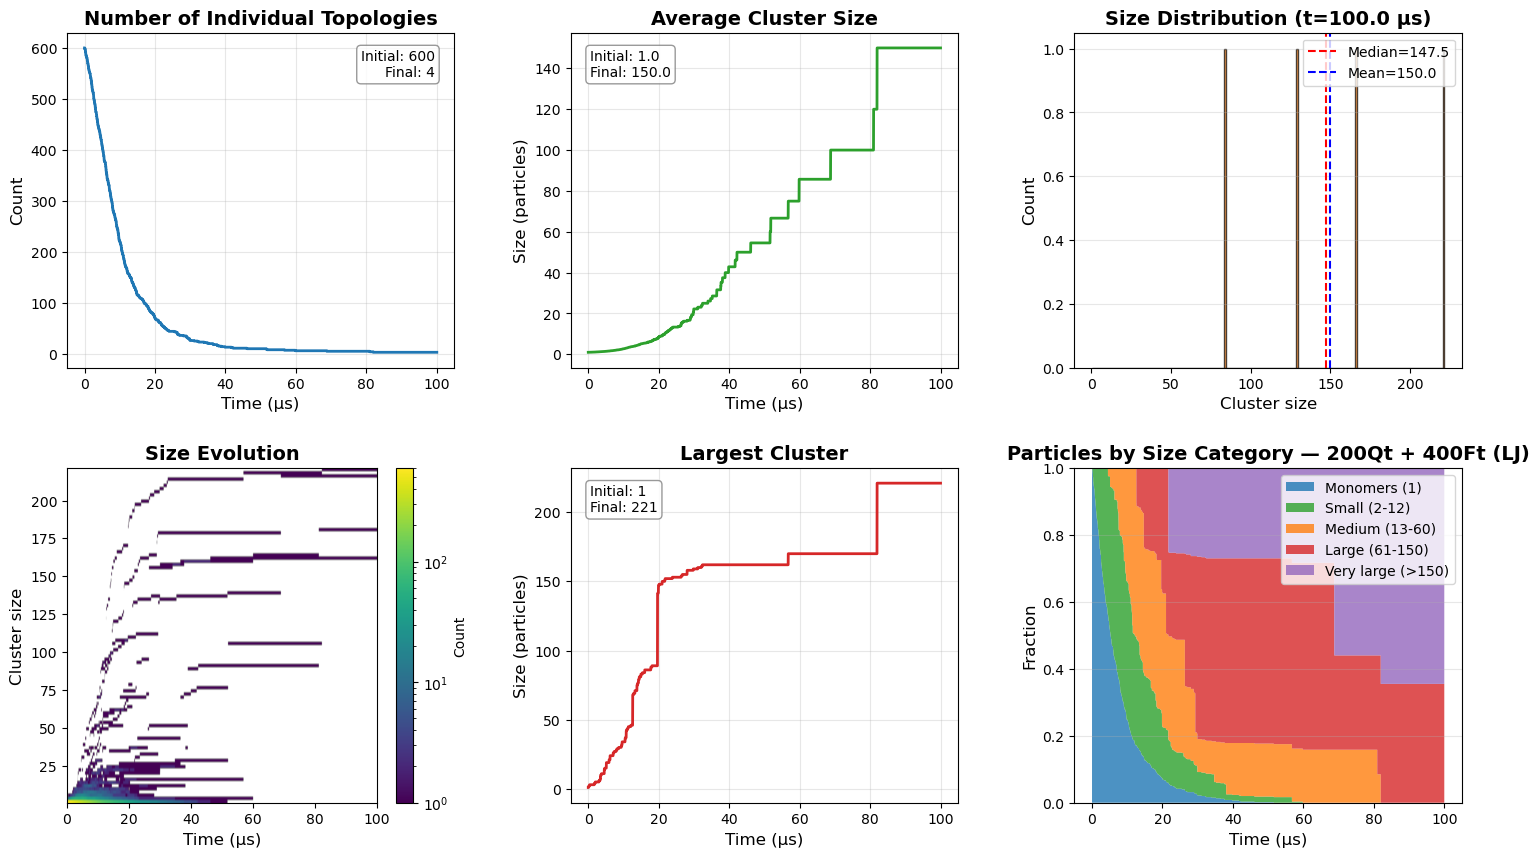

In [17]:
# Plot observables
print("\nGenerating observable plots...")
data = plotting.plot_observables(config.output_file, config, save_path="plots_observables.svg" if SAVE_PLOTS else None)

# Plot cluster analysis
print("\nGenerating cluster analysis plots...")
cluster_stats = plotting.plot_cluster_analysis(config.output_file, config=config, save_path="plots_clusters.svg" if SAVE_PLOTS else None)

## 5. Export for Visualization

In [15]:
# Derive xyz filename from the h5 output filename
xyz_file = config.output_file.replace(".h5", ".xyz")
xyz_path = analysis.convert_h5_to_xyz(config.output_file, xyz_file, config, overwrite=True)

✓ Exported OVITO-friendly XYZ to Simulation_Files_Single_Runs/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us.xyz


## 6. Structural Cluster Analysis


COMPUTING STRUCTURAL CLUSTER ANALYSIS

[1/5] Extracting frame data...
    Using particles observable for data extraction


    Processing frames: 100%|██████████| 2001/2001 [00:01<00:00, 1208.29frame/s]


       Extracted 2001 frames

[2/5] Morphology analysis...


  Morphology: 100%|██████████| 2001/2001 [00:12<00:00, 161.31frame/s]



[3/5] Binding kinetics analysis...
  Bond counting: Method 1 (topology.edges) - exact count

[4/5] Spatial distribution analysis...


...


[5/5] Contact analysis...


  Contacts: 100%|██████████| 2001/2001 [00:00<00:00, 2594.29frame/s]



✓ Structural analysis complete

Generating structural analysis plots...


/home/befe/readdySimulations/Qt_Ft_Simulation_16/qtft/plotting.py:569: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ Saved plot to plots_structural_analysis.svg


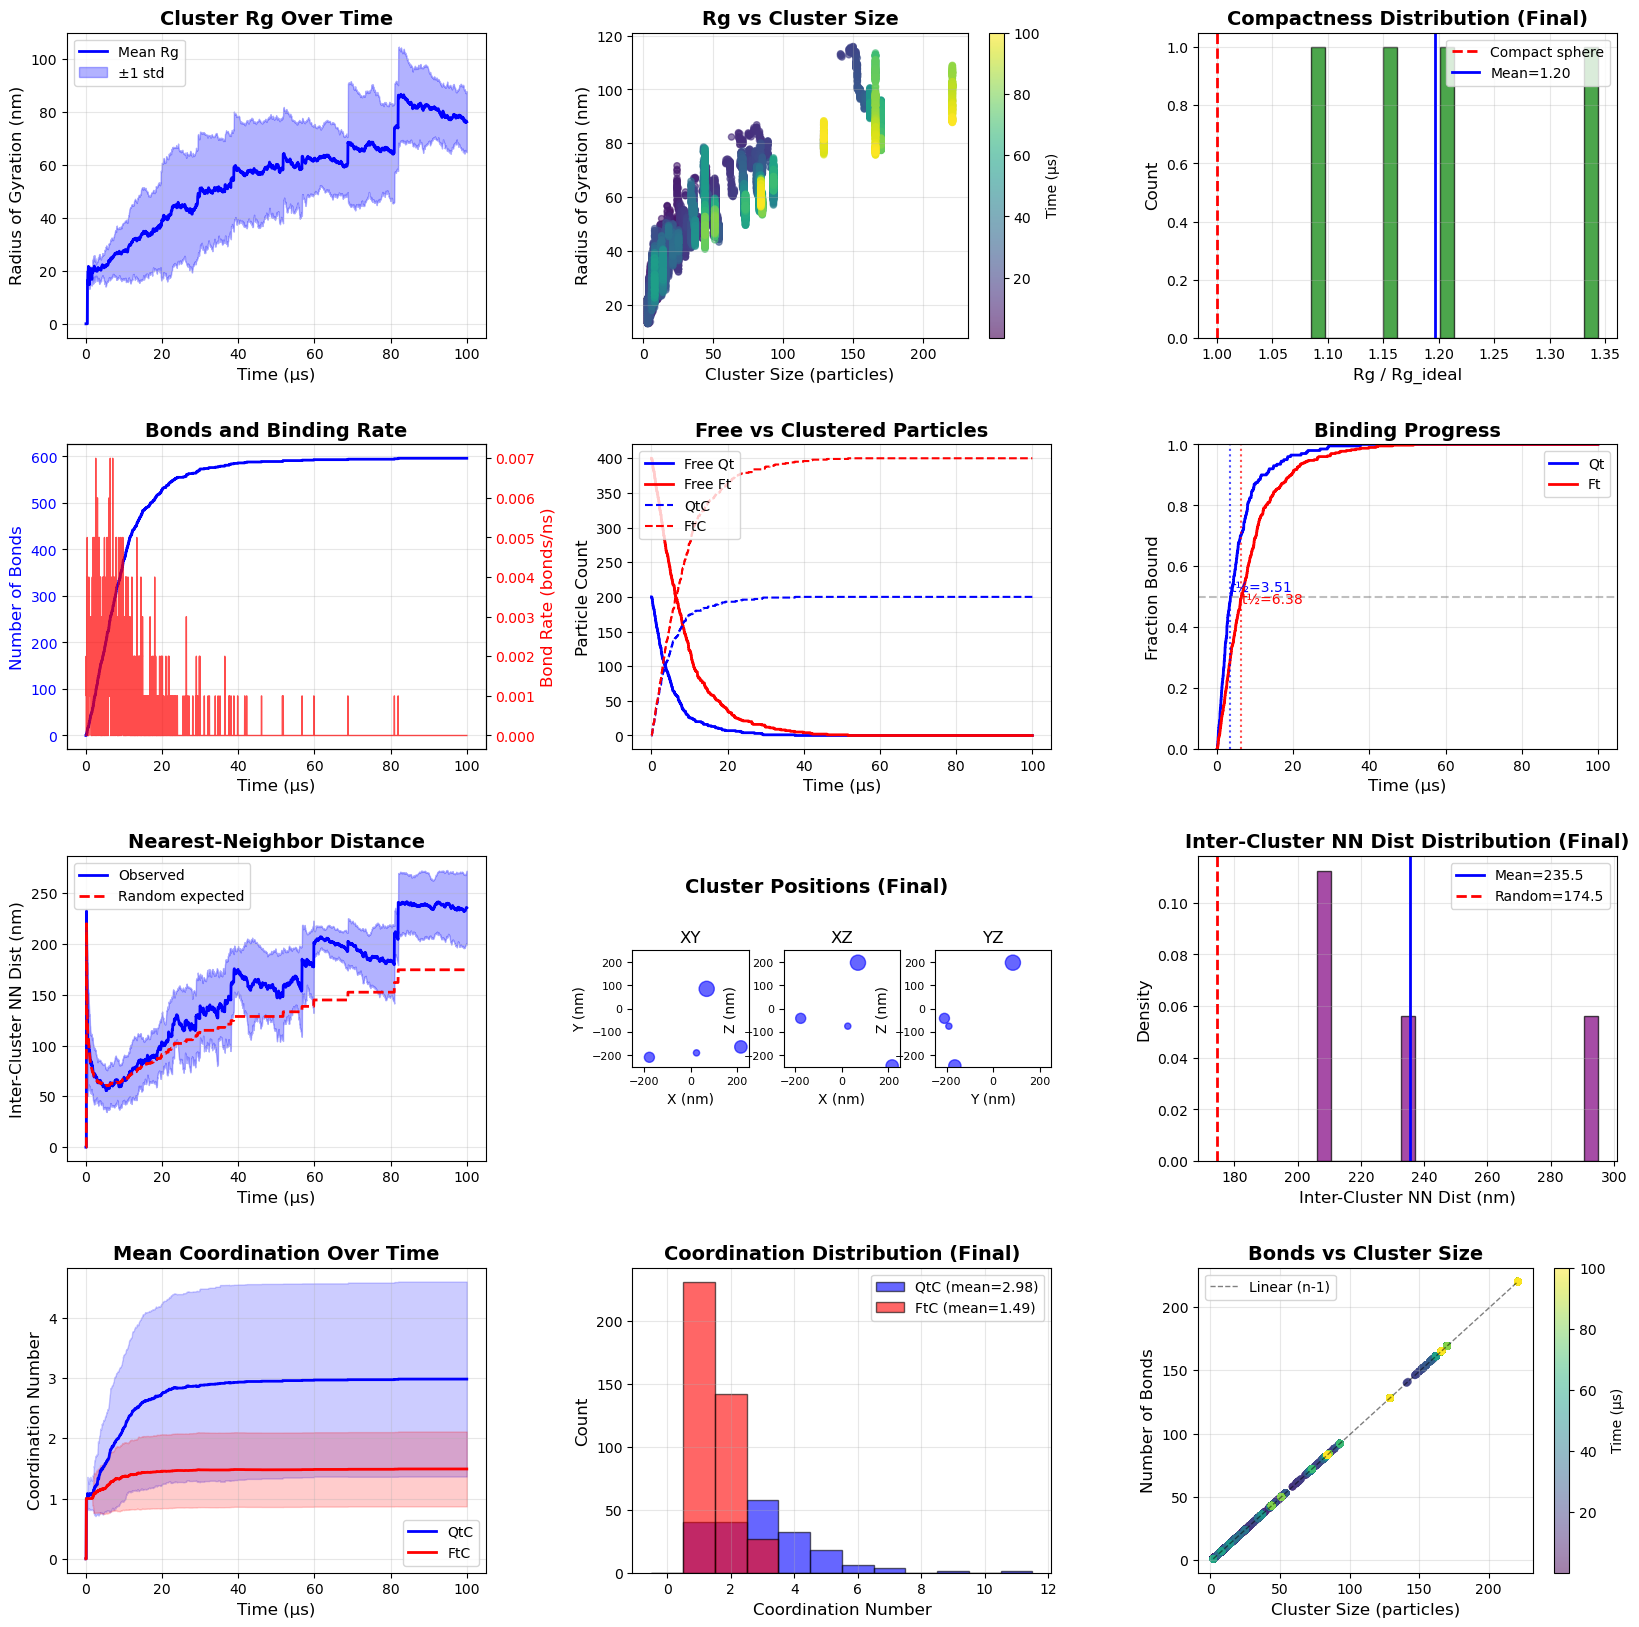

In [18]:
structural_data = plotting.plot_structural_cluster_analysis(
    config.output_file,
    config,
    save_path="plots_structural_analysis.svg" if SAVE_PLOTS else None,
    stride=1,
    min_cluster_size_morphology=3,
    min_cluster_size_spatial=2,
)

## 7. Cluster Composition Analysis


CLUSTER COMPOSITION ANALYSIS
  Extracting frame data for composition analysis...
    Using particles observable for data extraction


  Composition: 100%|██████████| 2001/2001 [00:00<00:00, 4045.05frame/s]



Generating composition plots...

✓ Saved plot to plots_cluster_composition.svg


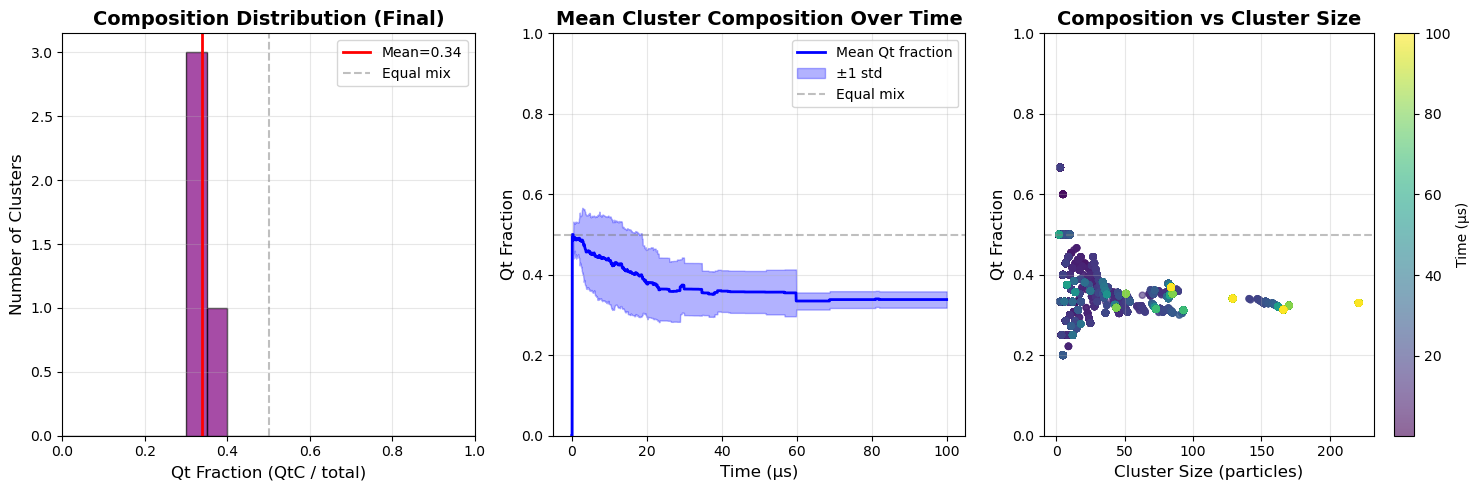


COMPOSITION ANALYSIS COMPLETE



In [19]:
composition_data = plotting.plot_cluster_composition(
    config.output_file,
    config,
    save_path="plots_cluster_composition.svg" if SAVE_PLOTS else None,
    stride=1,
    min_cluster_size=2,
)

## 8. Save Configuration

In [20]:
# Save config alongside the run's other output, sharing the h5 base name + "_config" tag.
_cfg_path = config.output_file[:-3] + "_config.json"   # ".h5" -> "_config.json"
config.save_json(_cfg_path)
# To load: config = sim.SimulationConfig.load_json(_cfg_path)

✓ Configuration saved to Simulation_Files_Single_Runs/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us_config.json


## 9. Ensemble Simulations

In [4]:
# ============================================================
# CREATE ENSEMBLE
# ============================================================
# The folder name is auto-generated from simulation parameters:
#   {name}_{n_qt}Qt_{n_ft}Ft_dt{timestep}ps_{total_time}us
#
# Examples:
#   - name=None:       200Qt_400Ft_dt10ps_30us/
#   - name="highFt":   highFt_200Qt_400Ft_dt10ps_30us/

ensemble = EnsembleSimulation(
    base_config=config,
    n_replicas=10,
    name=None,           # Optional: descriptive name prefix (e.g., "test", "highFt")
    base_dir="Different_Particle_Ratios",        # Base directory for output (folder created as subdirectory)
)

print(f"Seeds: {ensemble.seeds}")

✓ Ensemble created: 200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us
  Output directory: Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/
  Replicas: 10
Seeds: [1950464737, 2539317803, 3333880692, 2150020773, 2633213151, 1529125172, 4010032112, 3532649711, 2858885004, 2799241814]


In [5]:
# ============================================================
# Option A: Run locally
# ============================================================
# After completion, automatically:
#   - Collects results from all replicas
#   - Computes statistics
#   - Saves JSON/NPZ files for plotting

ensemble.run_local(
    parallel=True,           # Run replicas in parallel
    n_workers=10,             # Number of parallel workers
    overwrite=True,          # Overwrite existing output directory
    equilibration_steps=10000,
    
    
)

✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_000.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_001.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_002.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_003.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_004.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_005.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_006.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eF

✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_003.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_000.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_002.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_004.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_001.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_007.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/configs/config_006.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_40

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:09<00:00, 103.30it/s]



EQUILIBRATION COMPLETE
  Retrieved 200 Qt + 400 Ft positions


...

    ✓ morphology / spatial / contacts / composition

  Replica 8 (9/10):


  Composition: 100%|██████████| 201/201 [00:00<00:00, 1577.13frame/s]


    ✓ morphology / spatial / contacts / composition

  Replica 9 (10/10):


  Composition: 100%|██████████| 201/201 [00:00<00:00, 1560.77frame/s]


    ✓ morphology / spatial / contacts / composition

Processing structural data...
  Computing size fractions...
    ✓ Size fractions (5 categories)
✓ Structural statistics computed
✓ Saved statistics to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_statistics.json
✓ Saved configuration to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_config.json
✓ Saved structural data to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_structural.npz
✓ Saved ensemble state to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_state.json
✓ Saved ensemble state to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_state.json

ENSEMBLE COMPLETE
Output directory: Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/
Analysis files saved for plotting



In [ ]:
# ============================================================
# Option B: Generate SLURM scripts for cluster execution
# ============================================================

# ----- SLURM script for running replica simulations -----
ensemble.generate_slurm_scripts(
    # --- SLURM job settings ---
    partition="cm4_tiny",        # (required, str) SLURM partition name
    cluster="cm4",               # (optional, str) SLURM cluster name, None to omit
    qos="cm4_tiny",              # (optional, str) Quality of service, None to omit
    time="08:00:00",             # (optional, str) Wall time limit per replica (HH:MM:SS)
    cpus_per_task=12,            # (optional, int) CPUs per replica
    memory="32G",                # (optional, str) Memory per replica
    
    # --- Conda environment ---
    conda_base="<YOUR_CONDA_PATH>",  # (required, str) Full path to conda installation, e.g. "/home/user/miniconda3"
    conda_env="readdy",              # (optional, str) Name of conda environment with ReaDDy
    
    # --- Paths ---
    scripts_dir="~/Readdy_Simulations",  # (optional, str) Directory where Python scripts are located
    
    # --- Email notifications ---
    mail_user=None,              # (optional, str) Email for notifications, e.g. "user@example.com"
    mail_type="ALL",             # (optional, str) When to send emails: NONE, BEGIN, END, FAIL, ALL
)

# ----- SLURM script for post-simulation analysis -----
ensemble.generate_analysis_slurm_script(
    # --- SLURM job settings ---
    partition="cm4_tiny",        # (required, str) SLURM partition name
    cluster="cm4",               # (optional, str) SLURM cluster name, None to omit
    qos="cm4_tiny",              # (optional, str) Quality of service, None to omit
    time="04:00:00",             # (optional, str) Wall time limit (HH:MM:SS)
    cpus_per_task=4,             # (optional, int) CPUs for parallel analysis
    memory="32G",                # (optional, str) Memory allocation
    
    # --- Conda environment ---
    conda_base="<YOUR_CONDA_PATH>",  # (required, str) Full path to conda installation, e.g. "/home/user/miniconda3"
    conda_env="readdy",              # (optional, str) Name of conda environment with ReaDDy
    
    # --- Paths and analysis settings ---
    scripts_dir="~/Readdy_Simulations",  # (optional, str) Directory where Python scripts are located
    stride=10,                           # (optional, int) Analyze every Nth frame for structural analysis
    
    # --- Email notifications ---
    mail_user=None,              # (optional, str) Email for notifications, e.g. "user@example.com"
    mail_type="ALL",             # (optional, str) When to send emails: NONE, BEGIN, END, FAIL, ALL
)

In [6]:
# Analyze results
ensemble.collect_results(require_all=False)
ensemble.compute_statistics()
ensemble.print_summary()


COLLECTING ENSEMBLE RESULTS
  Replica 0: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 1: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 2: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 3: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 4: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 5: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 6: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 7: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 8: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 9: Loading...
  Bond counting: Method 1 (topology.edges) - exact count

✓ Collected data from 10/10 replicas

Computing ensemble statistics...
  Time grids identical across replicas (20001 points)
✓ Statistics computed

ENSEMBLE SUM


Generating ensemble observable plots...
✓ Saved plot to ensemble_observables.svg


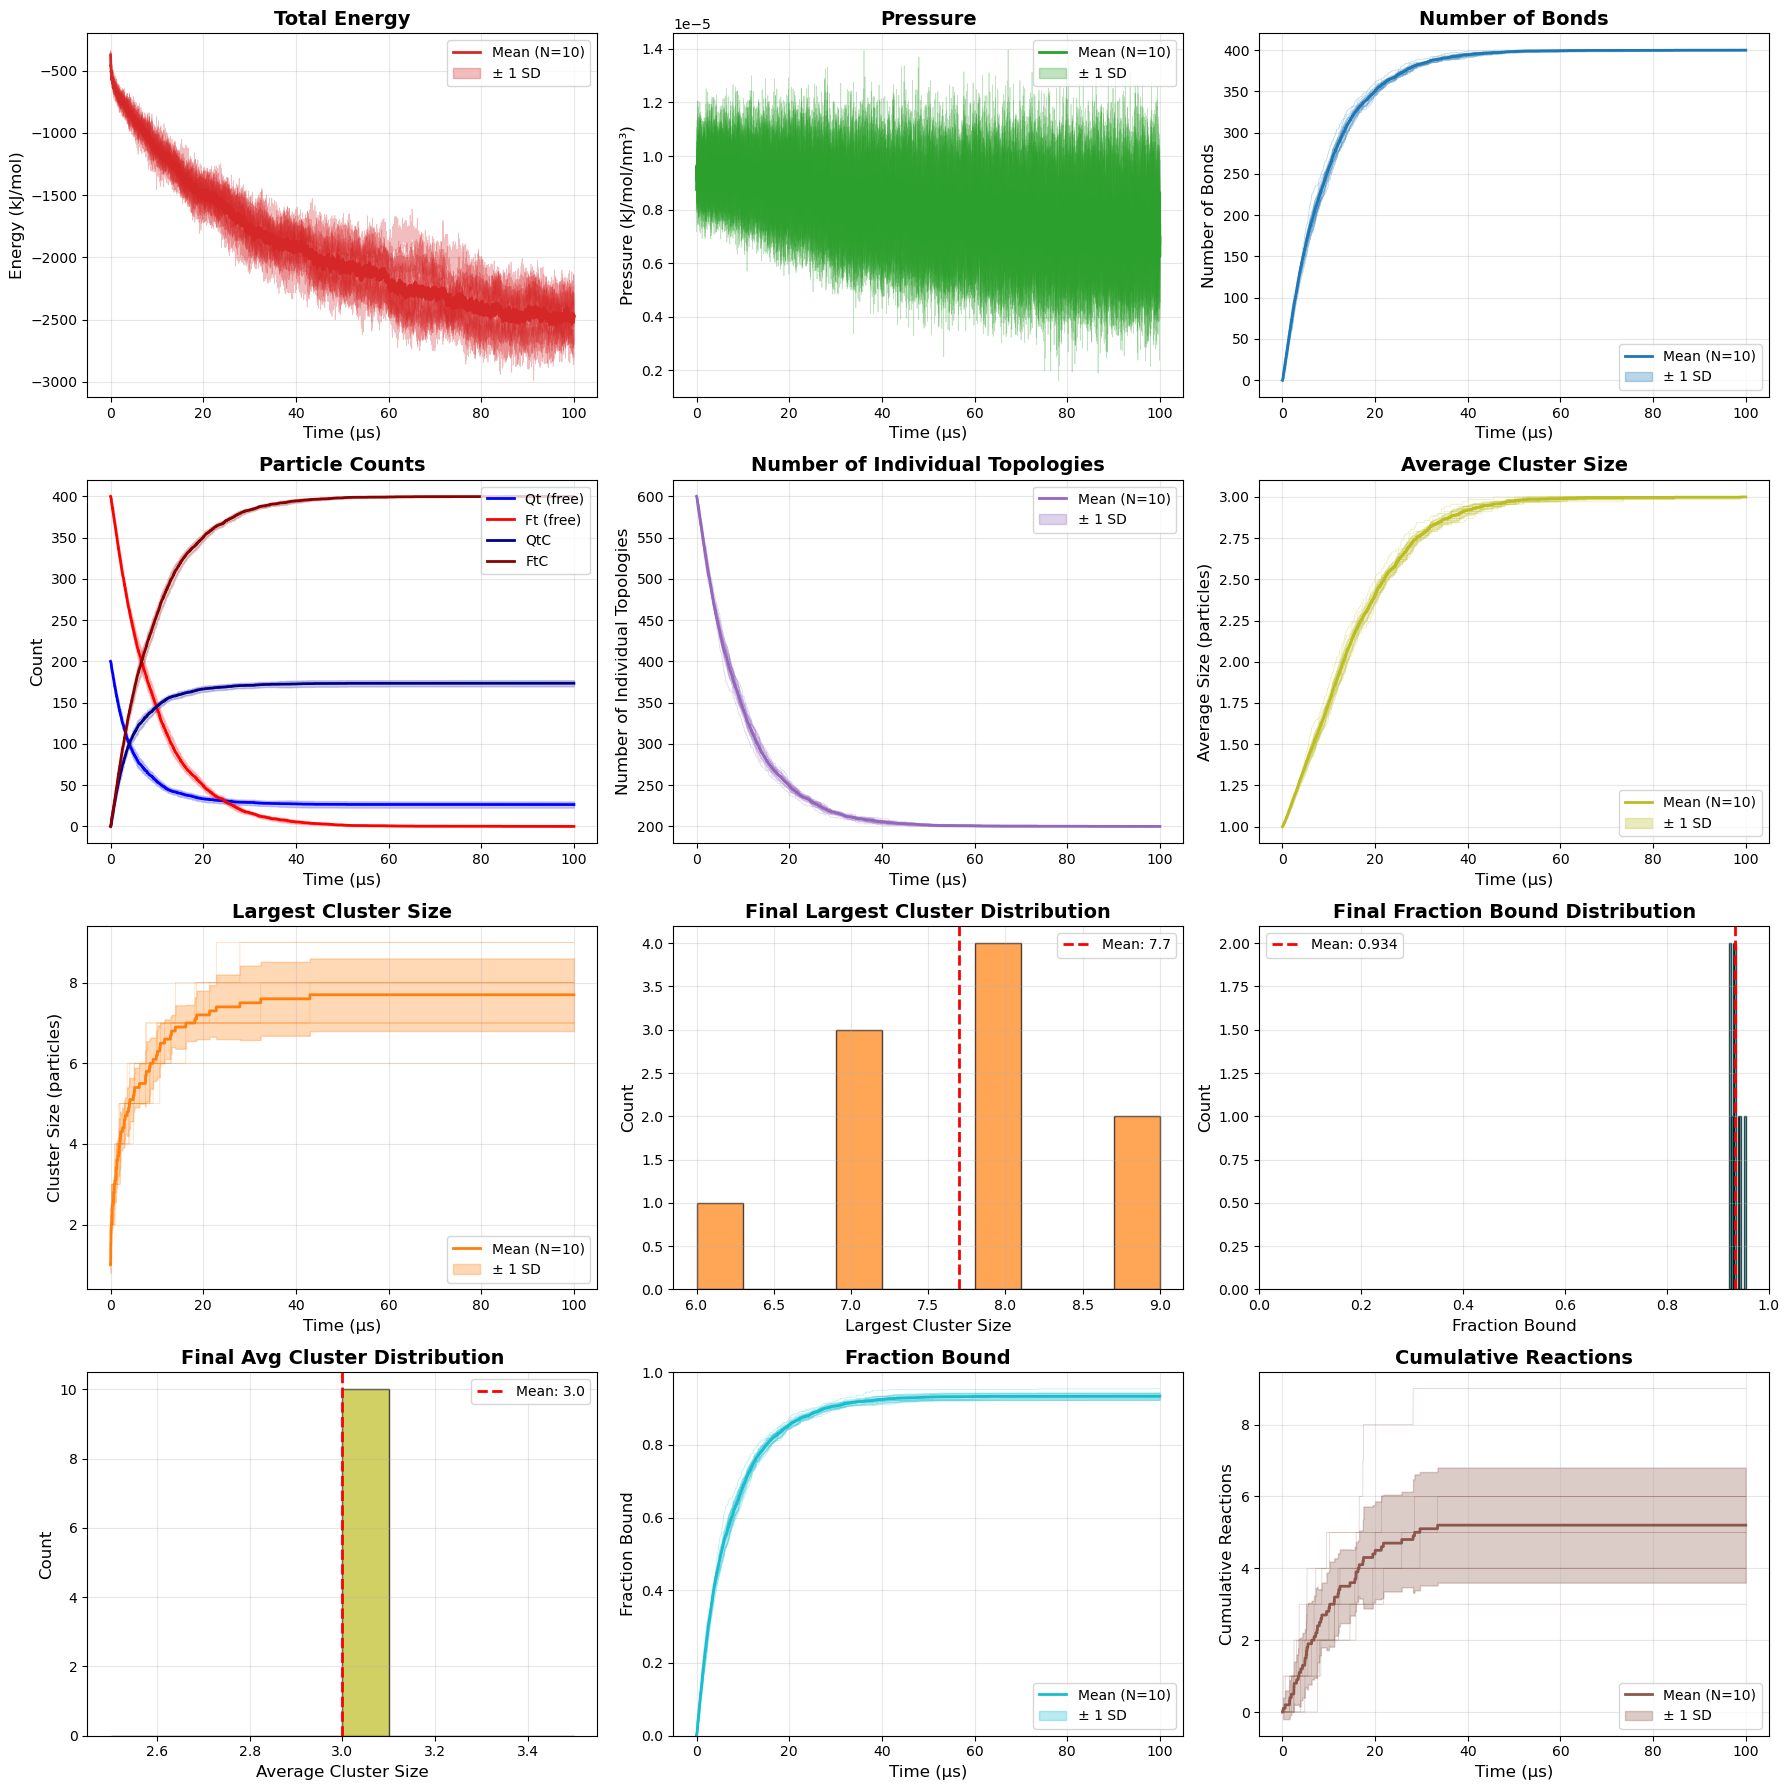

In [7]:
stats, structural, config_dict = ensemble.to_plotting_format()
fig = plotting.plot_ensemble_observables(
    stats, config_dict, structural,
    show_individual=True, save_path="ensemble_observables.svg",
)


Generating structural ensemble plots...
✓ Saved plot to ensemble_structural.svg


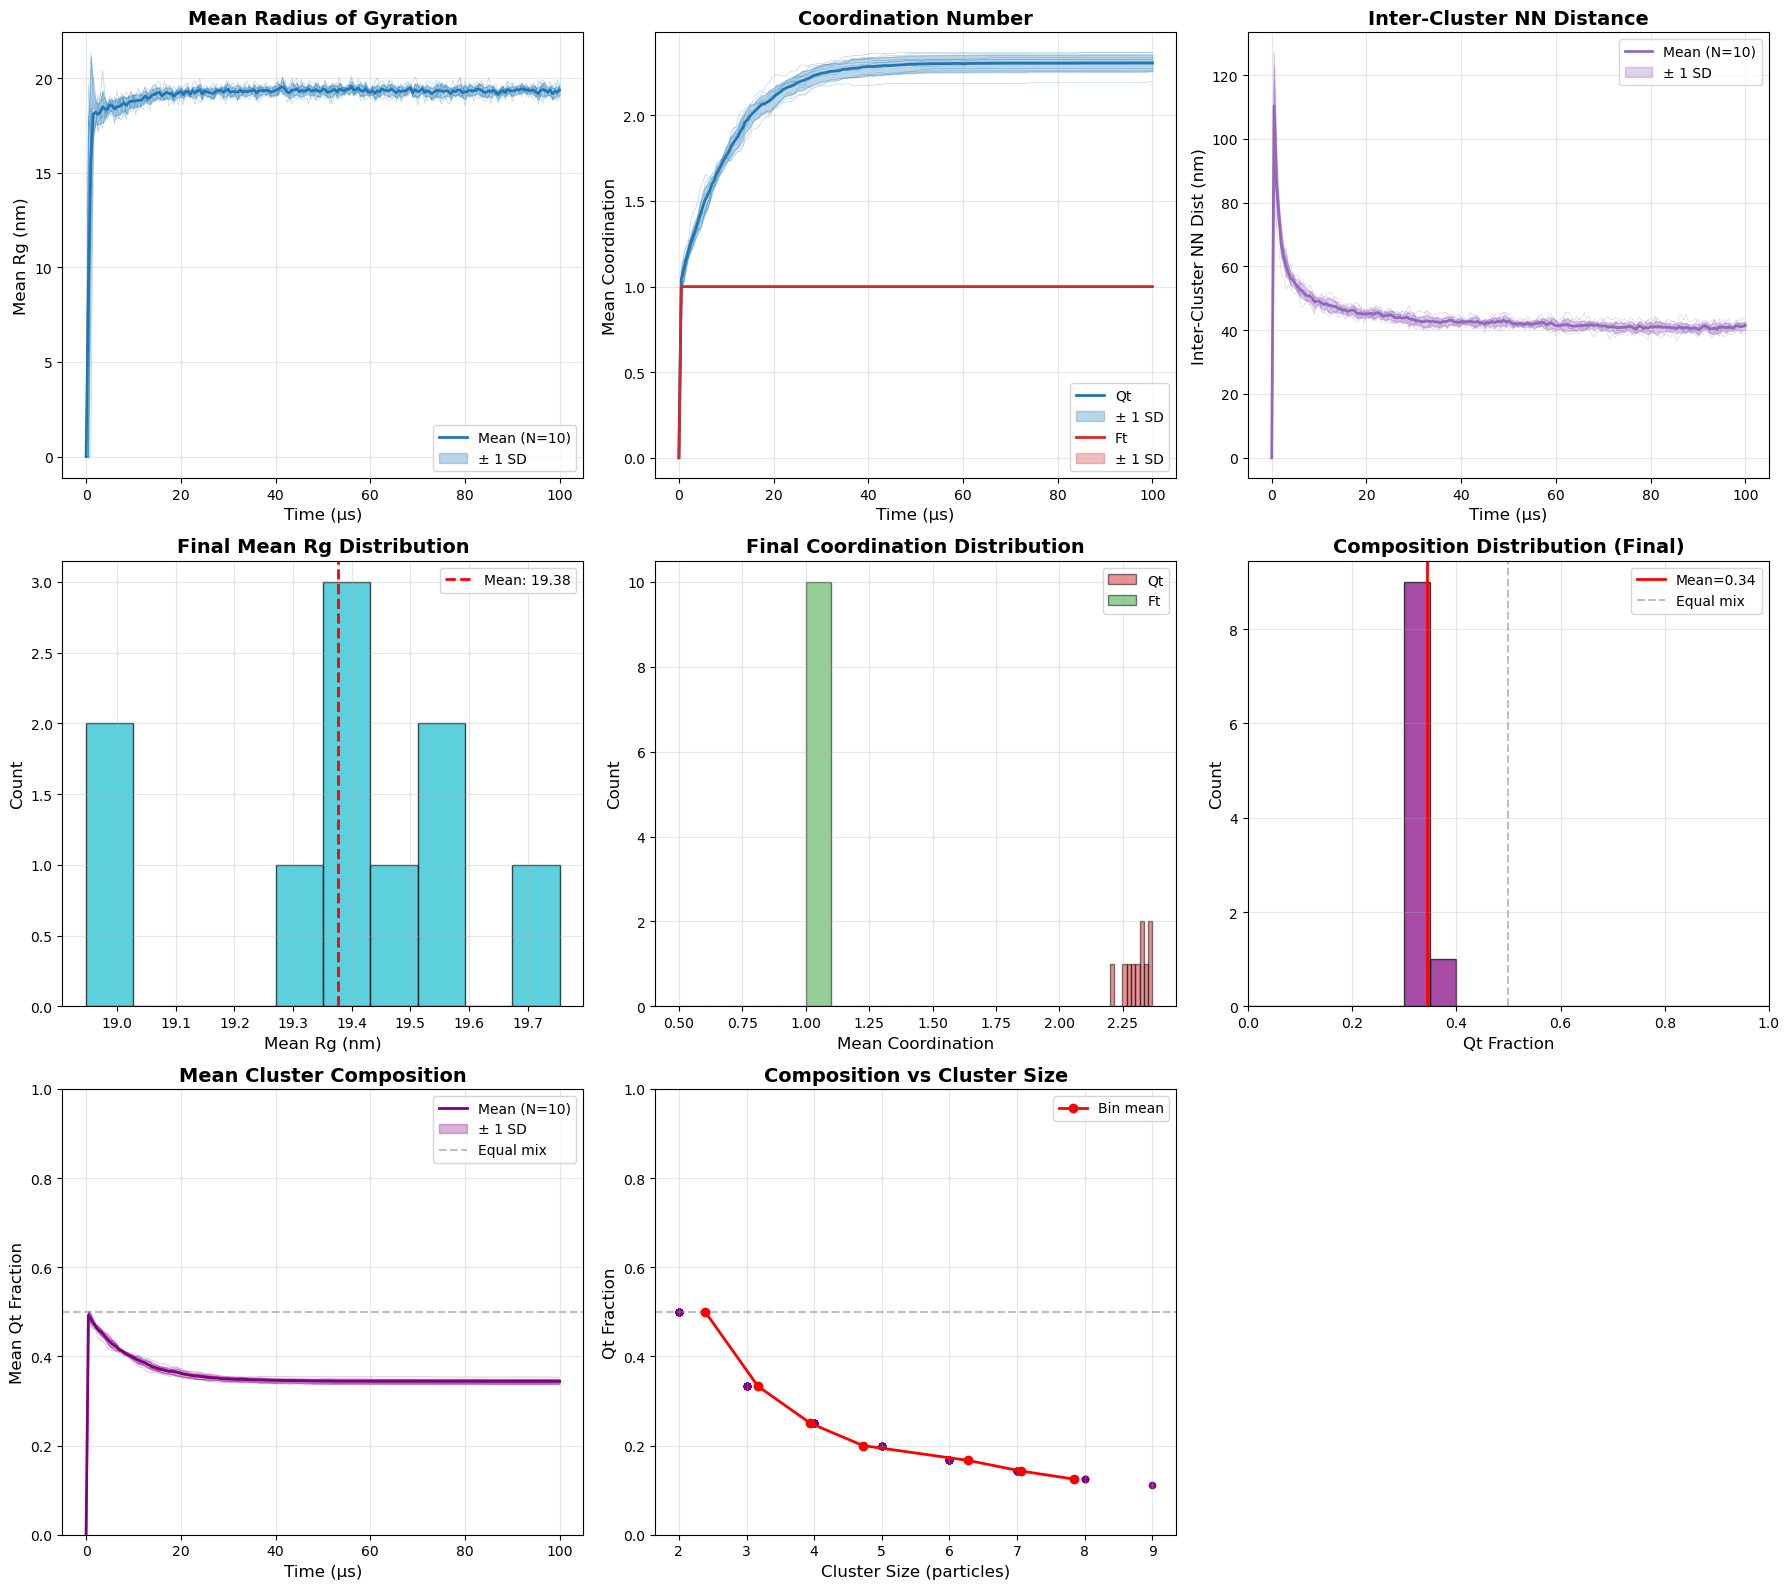

In [8]:
# Structural ensemble analysis
# Structural analysis is now computed automatically by run_local()
stats, structural, config_dict = ensemble.to_plotting_format()
fig = plotting.plot_ensemble_structural(
    stats, structural, config_dict,
    show_individual=True, save_path="ensemble_structural.svg",
)

## 10. Export Trajectory to XYZ (for OVITO)

In [4]:
# ============================================================
# EXPORT ENSEMBLE TRAJECTORY TO XYZ FOR OVITO VISUALIZATION
# ============================================================

# To reload an ensemble later (update path to match your ensemble folder):
ensemble = EnsembleSimulation.load("Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us")

# Select which replica to export (0 = first replica)
REPLICA_TO_EXPORT = 0

# Get the replica's config and trajectory path
replica_config = ensemble.replica_configs[REPLICA_TO_EXPORT]
h5_file = replica_config.output_file

# Output XYZ file in the same directory as the H5 file
import os
h5_dir = os.path.dirname(h5_file)
xyz_file = os.path.join(h5_dir, "trajectory.xyz")

print(f"Converting replica {REPLICA_TO_EXPORT}:")
print(f"  Input:  {h5_file}")
print(f"  Output: {xyz_file}")
print()

# Convert to XYZ
analysis.convert_h5_to_xyz(h5_file, xyz_file, replica_config, overwrite=True)

print(f"\nFile size: {os.path.getsize(xyz_file) / (1024*1024):.1f} MB")
print("\nOpen in OVITO: File -> Load File -> select the .xyz file")

✓ Loaded ensemble from Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/ensemble_state.json
Converting replica 0:
  Input:  Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/replica_000/trajectory.h5
  Output: Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/replica_000/trajectory.xyz

✓ Exported OVITO-friendly XYZ to Different_Particle_Ratios/200Qt_400Ft_WCA_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us/replica_000/trajectory.xyz

File size: 473.4 MB

Open in OVITO: File -> Load File -> select the .xyz file


In [ ]:
# ============================================================
# EXPORT MULTIPLE REPLICAS (optional)
# ============================================================
# Uncomment and run to export all replicas

# for i, replica_config in enumerate(ensemble.replica_configs):
#     h5_file = replica_config.output_file
#     if not os.path.exists(h5_file):
#         print(f"Replica {i}: SKIPPED (H5 file not found)")
#         continue
#     
#     h5_dir = os.path.dirname(h5_file)
#     xyz_file = os.path.join(h5_dir, "trajectory.xyz")
#     
#     print(f"Replica {i}: Converting...")
#     analysis.convert_h5_to_xyz(h5_file, xyz_file, replica_config, overwrite=True)
#     print(f"  -> {xyz_file} ({os.path.getsize(xyz_file) / (1024*1024):.1f} MB)")

## 11. Agglomeration ↔ Deagglomeration Cycle

Split a run into **phases** to model an agglomeration↔deagglomeration cycle. Each phase sets its own reactions and pair potential (see README §1):

- **agglomerate** — binding on, breaking off, attractive `LJ`
- **deagglomerate** — binding off, breaking on (bonds dissociate at `topology.koff`), repulsive `WCA` so freed particles disperse

Use `make_agg_deagg_phases(agg_steps, deagg_steps, n_cycles=...)` to build the schedule and set `topology.koff > 0`. ReaDDy runs each phase as a separate segment, carrying particle positions **and** bonds across phases via checkpoints; analysis stitches the per-phase trajectories onto one continuous time axis. Works for single runs and ensembles.

In [ ]:
# ============================================================
# AGGLOMERATION <-> DEAGGLOMERATION CYCLE (single run)
# ============================================================
# Build a phased schedule on top of the `config` above: an agglomeration phase
# (binding on, attractive LJ) followed by a deagglomeration phase (bonds break at
# `koff`, binding off, repulsive WCA so freed particles disperse). Increase n_cycles
# to repeat the cycle. run_one() dispatches to run_phased() automatically.
import copy

phased_config = copy.deepcopy(config)
phased_config.topology.koff = 5e-4        # bond-breaking rate per edge (1/ns); tune to taste
phased_config.phases = sim.make_agg_deagg_phases(
    agg_steps=1_000_000,                  # 50 µs agglomeration (dt = 50 ps)
    deagg_steps=1_000_000,                # 50 µs deagglomeration
    n_cycles=1,                           # repeat agg->deagg this many times
)

# Give the phased run its own output folder (leaves the single-run output above intact).
# Each phase writes <PHASED_DIR>/<name>/phase_NNN/trajectory.h5.
phased_name = sim.format_param_string(phased_config)
PHASED_DIR = os.path.join(OUTPUT_ROOT, phased_name)
os.makedirs(PHASED_DIR, exist_ok=True)
phased_config.output_file = os.path.join(PHASED_DIR, phased_name + ".h5")
phased_config.print_summary()

# Run all phases (equilibrate -> phase 0 -> checkpoint -> phase 1 -> ...).
phase_results = sim.run_one(phased_config, equilibration_steps=10000)

# Stitch the per-phase trajectories onto one continuous time axis and plot the cycle.
fig = plotting.plot_phased_kinetics(
    phased_config,
    save_path=os.path.join(PHASED_DIR, "phased_kinetics.svg") if SAVE_PLOTS else None,
)

In [ ]:
# ============================================================
# AGGLOMERATION <-> DEAGGLOMERATION CYCLE (ensemble)
# ============================================================
# Phased runs work as ensembles too: each replica inherits cycling via run_one(),
# and result collection stitches every replica's phases onto one continuous time axis
# before averaging (ensemble_statistics.json / ensemble_structural.npz keep their format).

phased_ensemble = EnsembleSimulation(
    base_config=phased_config,   # the phased config built in the cell above
    n_replicas=10,
    name=None,
    base_dir="Different_Particle_Ratios",
)
phased_ensemble.run_local(
    parallel=True, n_workers=10, overwrite=True, equilibration_steps=10000,
)

# Ensemble mean kinetics (stitched across phases) live in phased_ensemble.statistics.
stats, structural, cfg = phased_ensemble.to_plotting_format()
print("Final mean fraction bound:", stats["fraction_bound_mean"][-1])

# Illustrate one replica's stitched agglomeration/deagglomeration curve.
fig = plotting.plot_phased_kinetics(phased_ensemble.replica_configs[0])